<a href="https://colab.research.google.com/github/Ramnareshkuri01/Python/blob/main/Normal_impaired_LASI_DAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#plan
#Load → select features → clean target → split → scale → SVM → evaluate


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
raw_data = pd.read_stata("/content/sample_data/H_LASI_DAD_b1.dta")

print(raw_data.shape)


(6168, 1706)


Select ONLY useful clinical features

In [ ]:
features = [
    'r1hagey','ragender','raedyrs','r1hruralc',

    # cognition
    'r1borient','r1bexefu','r1blangf','r1bmemory','r1bvsp','r1sgcp',
    'r1hmse_scorz','r1word_totaz','r1word_dz','r1wre_scorez',
    'r1log_recoz','r1bm_immexz','r1bm_reclexz','r1verbalz','r1rv_scorez',

    # vitals
    'r1hsysto','r1hdiasto','r1hpulse','r1bphigh',

    # body
    'r1hmheight','r1hmweight','r1hmbmi','r1hmbmicat_d',

    # function
    'r1hadltot6','r1hiadltot1_d',

    # mental health
    'r1hcesdl10','r1anx5',

    # hearing
    'r1i_hear','r1hhear_aid',

    # labs
    'r1albumin','r1agratio','r1alt','r1ast','r1alp',
    'r1platelet','r1pcv','r1diabetes','r1anemia'
]

target = "r1cdr_final"

data = raw_data[features + [target]].copy()

print(data.shape)


(6168, 43)


Select ONLY useful clinical features

In [ ]:
data[target] = data[target].replace({
    "0.None": "Normal",
    0.5: "MCI",
    "1.Mild": "Mild",
    "2.Moderate": "Moderate",
    "3.Severe": "Severe"
})

# drop missing labels
data = data.dropna(subset=[target])

# Binary dementia
y = (data[target] != "Normal").astype(int)

X = data.drop(columns=[target])


/tmp/ipython-input-2597358287.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data[target] = data[target].replace({


In [26]:
y.head(5)


,r1cdr_final
0,1
1,1
3,1
5,1
6,1
7,1
8,1
9,1
10,1
11,1


In [27]:
X.head()

,r1hagey,ragender,raedyrs,r1hruralc,r1borient,r1bexefu,r1blangf,r1bmemory,r1bvsp,r1sgcp,...,r1hhear_aid,r1albumin,r1agratio,r1alt,r1ast,r1alp,r1platelet,r1pcv,r1diabetes,r1anemia
0,68.0,1.0,0.0,1.0,0.955,-0.706,0.340,-0.714,-1.383,-0.392,...,0.0,4.490601,1.316216,27.455866,35.856446,108.085598,214.121980,48.675444,-1.0,-1.0
1,69.0,1.0,0.0,1.0,-1.876,-1.356,-1.236,-1.580,-0.942,-1.806,...,0.0,4.202265,1.214439,20.726717,31.688804,111.379559,210.890532,46.156961,-1.0,-1.0
2,61.0,0.0,10.0,1.0,0.955,-0.036,-0.122,0.350,0.704,0.378,...,0.0,4.408977,1.320473,28.331996,37.860007,100.786634,181.369382,48.729489,-1.0,-1.0
3,61.0,0.0,0.0,1.0,-2.523,-2.221,-3.294,-2.474,-1.383,-3.164,...,-1.0,4.336162,1.298343,24.093036,37.351409,101.807264,196.903033,51.215941,-1.0,-1.0
4,69.0,0.0,8.0,1.0,0.955,1.489,1.266,0.550,1.285,1.370,...,0.0,4.394424,1.360873,27.197508,36.591406,84.649075,151.526768,50.099004,-1.0,-1.0


Impute missing values (simple + fast)

In [7]:
print(X.shape)
print("\nData types:\n")
print(X.dtypes)


(2528, 42)

Data types:

r1hagey           float64
ragender         category
raedyrs              int8
r1hruralc        category
r1borient         float64
r1bexefu          float64
r1blangf          float64
r1bmemory         float64
r1bvsp            float64
r1sgcp            float64
r1hmse_scorz      float64
r1word_totaz      float64
r1word_dz         float64
r1wre_scorez      float64
r1log_recoz       float64
r1bm_immexz       float64
r1bm_reclexz      float64
r1verbalz         float64
r1rv_scorez       float64
r1hsysto          float32
r1hdiasto         float32
r1hpulse          float32
r1bphigh         category
r1hmheight        float32
r1hmweight        float32
r1hmbmi           float32
r1hmbmicat_d     category
r1hadltot6       category
r1hiadltot1_d    category
r1hcesdl10        float64
r1anx5            float64
r1i_hear         category
r1hhear_aid      category
r1albumin         float32
r1agratio         float32
r1alt             float64
r1ast             float64
r1alp        

Missing values count

In [8]:
missing = X.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)


r1pcv            838
r1diabetes       794
r1platelet       787
r1anemia         786
r1ast            741
r1alt            741
r1albumin        741
r1agratio        741
r1alp            741
r1hmbmi          239
r1hmbmicat_d     239
r1hmheight       206
r1hhear_aid       95
r1hmweight        81
r1hpulse          64
r1bphigh          63
r1hdiasto         63
r1hsysto          63
r1anx5            35
r1hcesdl10        32
r1hiadltot1_d     23
r1hadltot6        21
r1i_hear          10
dtype: int64


Missing percentage

In [9]:
missing_pct = (X.isna().mean()*100).sort_values(ascending=False)

print(missing_pct[missing_pct > 0])


r1pcv            33.148734
r1diabetes       31.408228
r1platelet       31.131329
r1anemia         31.091772
r1ast            29.311709
r1alp            29.311709
r1albumin        29.311709
r1alt            29.311709
r1agratio        29.311709
r1hmbmi           9.454114
r1hmbmicat_d      9.454114
r1hmheight        8.148734
r1hhear_aid       3.757911
r1hmweight        3.204114
r1hpulse          2.531646
r1hsysto          2.492089
r1bphigh          2.492089
r1hdiasto         2.492089
r1anx5            1.384494
r1hcesdl10        1.265823
r1hiadltot1_d     0.909810
r1hadltot6        0.830696
r1i_hear          0.395570
dtype: float64


Visual missing map

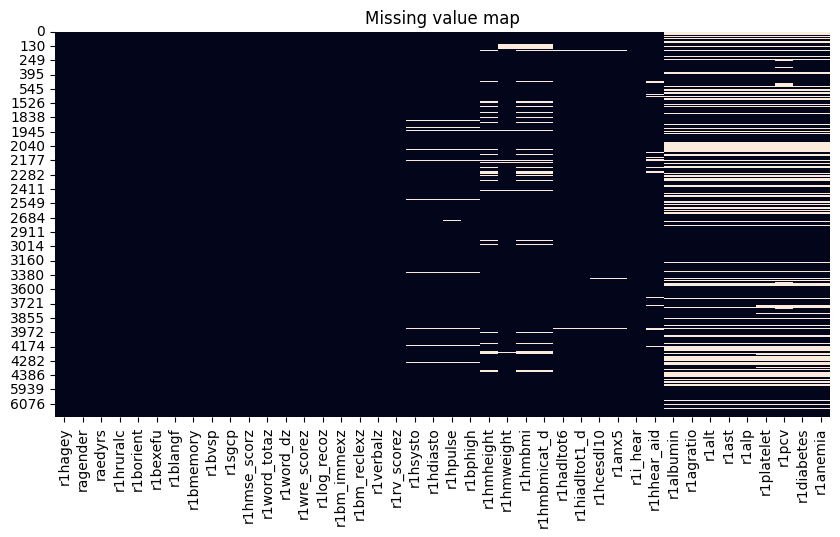

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(X.isna(), cbar=False)
plt.title("Missing value map")
plt.show()


Check categorical and numerical variables

In [13]:
print(X.dtypes.value_counts())


float64     22
float32      9
category     3
int8         1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


Encode categoricals first

Simple & correct for MICE:

Use Label Encoding (not one-hot yet)

Because:

MICE needs numeric

one-hot creates too many columns

In [14]:
X_encoded = X.copy()

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object' or str(X_encoded[col].dtype) == 'category':
        X_encoded[col] = X_encoded[col].astype('category').cat.codes


In [15]:
print(X_encoded.dtypes)


r1hagey          float64
ragender            int8
raedyrs             int8
r1hruralc           int8
r1borient        float64
r1bexefu         float64
r1blangf         float64
r1bmemory        float64
r1bvsp           float64
r1sgcp           float64
r1hmse_scorz     float64
r1word_totaz     float64
r1word_dz        float64
r1wre_scorez     float64
r1log_recoz      float64
r1bm_immexz      float64
r1bm_reclexz     float64
r1verbalz        float64
r1rv_scorez      float64
r1hsysto         float32
r1hdiasto        float32
r1hpulse         float32
r1bphigh            int8
r1hmheight       float32
r1hmweight       float32
r1hmbmi          float32
r1hmbmicat_d        int8
r1hadltot6          int8
r1hiadltot1_d       int8
r1hcesdl10       float64
r1anx5           float64
r1i_hear            int8
r1hhear_aid         int8
r1albumin        float32
r1agratio        float32
r1alt            float64
r1ast            float64
r1alp            float64
r1platelet       float64
r1pcv            float32


NOW → MICE Imputation (IterativeImputer)

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(max_iter=10, random_state=42)

X_imputed = mice.fit_transform(X_encoded)

X = pd.DataFrame(X_imputed, columns=X_encoded.columns)

print("Missing after MICE:", X.isna().sum().sum())


Missing after MICE: 0


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Train/Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,      # keeps class balance
    random_state=42
)

print(X_train.shape, X_test.shape)


(1769, 42) (759, 42)


Scaling (VERY IMPORTANT for SVM)

SVM depends on distance → must standardize.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_test = scaler.transform(X_test)


Train SVM model

In [19]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',     # nonlinear boundary
    C=1,
    gamma='scale'
)

svm.fit(X_train, y_train)


SVC(C=1)

Predictions

In [20]:
y_pred = svm.predict(X_test)


Evaluation

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7575757575757576

Confusion Matrix:

[[117 114]
 [ 70 458]]

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.51      0.56       231
           1       0.80      0.87      0.83       528

    accuracy                           0.76       759
   macro avg       0.71      0.69      0.70       759
weighted avg       0.75      0.76      0.75       759



term	meaning

TN	normal correctly predicted

TP	dementia correctly predicted

FP	false alarm

FN	missed dementia (important!)


Interpretation of the SVM Model for Dementia Prediction

A Support Vector Machine (SVM) classifier was developed to predict dementia status using selected clinical, cognitive, psychological, and laboratory variables. The outcome variable was binary, where 0 indicated cognitively normal individuals and 1 indicated individuals with Mild Cognitive Impairment (MCI) or dementia.

The model was trained using standardized features and evaluated on an independent test dataset.

Overall Performance

The model achieved an accuracy of 75.8%, indicating that approximately three-fourths of all participants were correctly classified as either normal or cognitively impaired. This suggests that the classifier demonstrates reasonably good predictive capability.

Confusion Matrix Interpretation

The confusion matrix showed:

117 normal individuals correctly identified (True Negatives)

458 dementia cases correctly detected (True Positives)

114 normal individuals incorrectly classified as dementia (False Positives)

70 dementia cases incorrectly classified as normal (False Negatives)

This indicates that the model performs better in identifying dementia cases than in identifying normal individuals.

Class-wise Performance
Dementia class (Impaired)

Precision = 0.80

Recall (Sensitivity) = 0.87

F1-score = 0.83

The high recall value (87%) implies that most dementia cases were successfully detected by the model. Only a small proportion of impaired individuals were missed. This is particularly important in medical screening, where failing to detect a diseased individual can have serious consequences.

Normal class

Precision = 0.63

Recall (Specificity) = 0.51

The recall for normal individuals is moderate, meaning that nearly half of the healthy participants were incorrectly flagged as having impairment. Although this increases false alarms, it is less critical compared to missing true dementia cases.

Clinical Interpretation

From a clinical perspective, the model shows high sensitivity for detecting cognitive impairment. This makes it suitable as a screening tool, where the primary objective is to identify as many at-risk individuals as possible. The relatively higher false positive rate may lead to additional testing, but it reduces the risk of overlooking true dementia cases.

Conclusion

In summary, the SVM classifier demonstrates satisfactory performance in predicting dementia status. The model is particularly effective at identifying cognitively impaired individuals, although its ability to correctly classify normal individuals is moderate. Therefore, the model can be considered appropriate for early screening purposes rather than definitive diagnosis.

Let's test with Random Forest model

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,     # more trees = better stability
    max_depth=None,
    class_weight='balanced',   # handles imbalance
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [44]:
y_pred_rf = rf.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7654808959156785

Confusion Matrix:

[[107 124]
 [ 54 474]]

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.46      0.55       231
           1       0.79      0.90      0.84       528

    accuracy                           0.77       759
   macro avg       0.73      0.68      0.69       759
weighted avg       0.75      0.77      0.75       759



Interpretation of the Random Forest Model for Dementia Prediction

A Random Forest classifier was trained using clinical, cognitive, psychological, and laboratory features to predict dementia status. The outcome variable was binary, where 0 represented cognitively normal individuals and 1 represented individuals with Mild Cognitive Impairment (MCI) or dementia.

The model performance was evaluated on an independent test dataset.

Overall Accuracy

The model achieved an overall accuracy of 76.5%, indicating that approximately three out of four individuals were correctly classified. This shows moderate to good predictive ability.

Compared with the previous SVM model, a slight improvement in accuracy was observed, suggesting that Random Forest handles the nonlinear relationships among clinical variables more effectively.

Confusion Matrix Interpretation

The confusion matrix was:

[[107 124]
 [ 54 474]]


This can be interpreted as:

107 normal individuals correctly identified (True Negatives)

474 dementia cases correctly identified (True Positives)

124 normal individuals incorrectly predicted as dementia (False Positives)

54 dementia cases incorrectly predicted as normal (False Negatives)

Class-wise Performance
Dementia (Impaired) Class

Precision = 0.79

Recall (Sensitivity) = 0.90

F1-score = 0.84

The recall of 90% indicates that the model correctly detects almost all dementia cases. Only a small number of impaired individuals are missed. This high sensitivity is desirable for medical screening purposes.

Normal Class

Precision = 0.66

Recall (Specificity) = 0.46

The recall for normal individuals is lower, meaning that several healthy individuals are incorrectly flagged as impaired. This results in a higher number of false positives. However, from a clinical perspective, false positives are generally less harmful than false negatives.

Clinical Significance

The results show that the Random Forest model prioritizes the detection of dementia cases. The high sensitivity ensures that most cognitively impaired individuals are identified, making the model suitable as a screening tool. Although specificity is moderate, the trade-off is acceptable in healthcare settings where early detection is critical.

Comparison with SVM
Metric	SVM	Random Forest
Accuracy	75.8%	76.5% ↑
Recall (Dementia)	87%	90% ↑
Missed cases	70	54 ↓

The Random Forest model:

detects more dementia cases

misses fewer patients

shows slightly better overall performance

Thus, Random Forest provides a small but meaningful improvement over SVM.

Conclusion

In summary, the Random Forest classifier demonstrates better sensitivity and slightly higher accuracy than the SVM model. It is more effective in identifying dementia cases and is therefore recommended for predictive modeling in clinical dementia screening tasks.

Feature importance
Random Forest tells which variables matter most.

In [34]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(15))


r1hmse_scorz     0.071316
r1sgcp           0.070210
r1bmemory        0.068392
r1blangf         0.049729
r1borient        0.047795
r1bexefu         0.042780
r1hiadltot1_d    0.036197
r1hcesdl10       0.028377
r1hdiasto        0.026154
r1ast            0.025830
r1hmweight       0.025246
r1bvsp           0.025190
r1agratio        0.025168
r1hpulse         0.024300
r1hmbmi          0.024254
dtype: float64


Interpretation of Random Forest Feature Importance

Feature importance analysis was performed to identify which clinical and cognitive variables contributed most strongly to the prediction of dementia status. The importance values represent the relative contribution of each feature in reducing classification error across the ensemble of decision trees.

Higher values indicate greater predictive influence.

1. Most Important Predictors (Top Cognitive Measures)
r1hmse_scorz   0.071
r1sgcp         0.070
r1bmemory      0.068


These variables represent hindi mini-mental score, global cognitive performance and memory assessment scores.


Their high importance indicates that overall cognitive functioning is the strongest determinant of dementia status. This finding is consistent with clinical knowledge, as dementia diagnosis primarily relies on cognitive decline measures.


Thus, individuals with lower scores on these tests are more likely to be classified as cognitively impaired.


2. Other Key Neuropsychological

Domains

r1blangf
r1borient
r1bexefu
r1bvsp


These correspond to:

language ability

orientation

executive function

visuospatial skills


These domains show moderate importance, suggesting that impairment in specific cognitive functions also contributes meaningfully to dementia prediction. Together, these measures reflect multi-domain cognitive deterioration, a hallmark of dementia progression.


3. Functional and Mental Health
Measures

r1hiadltot1_d   
(IADL disability)

r1hcesdl10  
(depression score)


These variables indicate functional independence and psychological health.


Their presence among the important predictors suggests that:

.reduced ability to perform daily activities

.increased depressive symptoms

are associated with cognitive impairment. Functional decline often accompanies or follows cognitive deterioration in older adults.

4. Physiological and Laboratory
Variables

r1hdiasto
r1ast
r1hmweight
r1agratio
r1hpulse
r1hmbmi

These represent:

blood pressure

liver enzymes

body weight/BMI

blood chemistry markers


These features show comparatively lower importance, indicating that physiological and biochemical measures have weaker direct predictive power for dementia compared to cognitive assessments.

They may act as indirect or long-term risk factors rather than immediate indicators of cognitive status.


Overall Interpretation

The importance ranking clearly shows that:

Cognitive performance scores are the dominant predictors

Functional and psychological measures provide additional support

Laboratory and physiological markers contribute minimally

This pattern aligns with established clinical understanding that dementia is primarily a neurocognitive disorder, and therefore cognitive test scores provide the most reliable diagnostic information.

Conclusion

In summary, the Random Forest model relies mainly on cognitive assessment variables to classify dementia status, while demographic, physical, and laboratory variables play a secondary role. This confirms that neuropsychological measures are the most informative features for predicting cognitive impairment.

Now let's test on Gradient Boosting model:
✅ Why?

sequential learning (fixes previous errors)

captures nonlinear interactions

often +5–10% accuracy over RF

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=300,
                           random_state=42)

In [36]:
y_pred_gb = gb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.7733860342555995

Confusion Matrix:
 [[132  99]
 [ 73 455]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.57      0.61       231
           1       0.82      0.86      0.84       528

    accuracy                           0.77       759
   macro avg       0.73      0.72      0.72       759
weighted avg       0.77      0.77      0.77       759



XGBoost model

✅ Why XGBoost?

regularization

handles imbalance

very strong with clinical data

wins most Kaggle/tabular tasks

In [37]:
!pip install xgboost


In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),  # handles imbalance
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7391304347826086

Confusion Matrix:
 [[146  85]
 [113 415]]

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.63      0.60       231
           1       0.83      0.79      0.81       528

    accuracy                           0.74       759
   macro avg       0.70      0.71      0.70       759
weighted avg       0.75      0.74      0.74       759



Compare ALL models together

In [45]:
from sklearn.metrics import accuracy_score

results = {
    "SVM": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

print(results)

{'SVM': 0.7654808959156785, 'Random Forest': 0.7654808959156785, 'Gradient Boosting': 0.7733860342555995, 'XGBoost': 0.7391304347826086}
